In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding,LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from matplotlib import pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
input_texts = [
    "The weather is nice today",
    "I need water",
    "Where is station",
    "hello",
    "good morning",
    "good evening",
    "I am hungry",
    "I love you",
    "The cat is sleeping",
    "Learning AI is fun"
]

output_texts = [
    "Das wetter ist heute schön",
    "Ich brauche Wasser",
    "Wo ist der Bahnhof",
    "Hallo",
    "Guten Morgen",
    "Guten Abend",
    "Ich habe Hunger",
    "Ich liebe dich",
    "Die Katze schläft",
    "KI zu lernen macht Spaß"
]

# Labels
# 1 = Positive
# 0 = Negative

labels = np.array([
    1, 1, 1, 1,
    0, 0, 0, 0
])

In [ ]:
# Create tokenizer object
tokenizer = Tokenizer()
tokenizer2 = Tokenizer()

# Learn all unique words from the dataset and assign an integer ID to each word
tokenizer.fit_on_texts(input_texts)
tokenizer2.fit_on_texts(output_texts)

# Create a dictionary:
# word -> integer ID
print("Word Index1:")
print(tokenizer.word_index)
print("Word Index2:")
print(tokenizer2.word_index)

# Convert each sentence into a sequence of numbers based on the word index
sequences = tokenizer.texts_to_sequences(input_texts)
sequences2 = tokenizer2.texts_to_sequences(output_texts)
print("\nSequences1:")
print(sequences)
print("\nSequences2:")
print(sequences2)


Word Index1:
{'is': 1, 'i': 2, 'the': 3, 'good': 4, 'weather': 5, 'nice': 6, 'today': 7, 'need': 8, 'water': 9, 'where': 10, 'station': 11, 'hello': 12, 'morning': 13, 'evening': 14, 'am': 15, 'hungry': 16, 'love': 17, 'you': 18, 'cat': 19, 'sleeping': 20, 'learning': 21, 'ai': 22, 'fun': 23}
Word Index2:
{'ich': 1, 'ist': 2, 'guten': 3, 'das': 4, 'wetter': 5, 'heute': 6, 'schön': 7, 'brauche': 8, 'wasser': 9, 'wo': 10, 'der': 11, 'bahnhof': 12, 'hallo': 13, 'morgen': 14, 'abend': 15, 'habe': 16, 'hunger': 17, 'liebe': 18, 'dich': 19, 'die': 20, 'katze': 21, 'schläft': 22, 'ki': 23, 'zu': 24, 'lernen': 25, 'macht': 26, 'spaß': 27}

Sequences1:
[[3, 5, 1, 6, 7], [2, 8, 9], [10, 1, 11], [12], [4, 13], [4, 14], [2, 15, 16], [2, 17, 18], [3, 19, 1, 20], [21, 22, 1, 23]]

Sequences2:
[[4, 5, 2, 6, 7], [1, 8, 9], [10, 2, 11, 12], [13], [3, 14], [3, 15], [1, 16, 17], [1, 18, 19], [20, 21, 22], [23, 24, 25, 26, 27]]


In [ ]:
X = pad_sequences(
    sequences,
    maxlen=4, # Maximum length of sequences. Shorter sequences will be padded, longer ones will be truncated
)
X2= pad_sequences(
    sequences2,
    maxlen=4, # Maximum length of sequences. Shorter sequences will be padded, longer ones will be truncated
)

print("\nPadded Sequences:")
print(X)
print("\nPadded Sequences2:")
print(X2)



Padded Sequences:
[[ 5  1  6  7]
 [ 0  2  8  9]
 [ 0 10  1 11]
 [ 0  0  0 12]
 [ 0  0  4 13]
 [ 0  0  4 14]
 [ 0  2 15 16]
 [ 0  2 17 18]
 [ 3 19  1 20]
 [21 22  1 23]]

Padded Sequences2:
[[ 5  2  6  7]
 [ 0  1  8  9]
 [10  2 11 12]
 [ 0  0  0 13]
 [ 0  0  3 14]
 [ 0  0  3 15]
 [ 0  1 16 17]
 [ 0  1 18 19]
 [ 0 20 21 22]
 [24 25 26 27]]


In [ ]:
input_size = len(tokenizer.word_index) + 1
output_size = len(tokenizer2.word_index) + 1
print(f"Input size: {input_size}")
print(f"Output size: {output_size}")

Input size: 24
Output size: 28


In [ ]:
model = Sequential()
model2 = Sequential()

# Embedding: converts word IDs → dense vectors
model.add(
    Embedding(
        input_dim=len(tokenizer.word_index) + 1, # Use the tokenizer from o0VLWw08wvJO
        output_dim=8, # From iaveH2Fdw-FS
        input_length=4 # From iaveH2Fdw-FS
    )
)

model2.add(
    Embedding(
        input_dim=len(tokenizer2.word_index) + 1, # Use the tokenizer from o0VLWw08wvJO
        output_dim=8, # From iaveH2Fdw-FS
        input_length=4 # From iaveH2Fdw-FS
    )
)


model.add(SimpleRNN(input_size,return_sequences=True))
model.add(SimpleRNN(8))
model.add(Dense(
        output_size,
 activation='sigmoid'
    )

)

# model2.add(SimpleRNN(16,return_sequences=True))
# model2.add(SimpleRNN(8))
# model2.add(Dense(
#         1,
#  activation='sigmoid'
#     )

# )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.summary()
model2.summary()

# Compile models before fitting
model.compile(
    optimizer='adam',
    loss='sparse_catergorical_crosstropy',
    metrics=['accuracy']
)
model2.compile(
    optimizer='adam',
    loss='sparse_catergorical_crosstropy',
    metrics=['accuracy']
)

history = model.fit(
    X,
    Y,# Removed slicing as labels now match X length
    labels,
    epochs=200,
    verbose=0
)
# model2 training history is not captured here if you intend to plot it separately
model2.fit(
    X2, # Removed slicing as labels now match X2 length
    labels,
    epochs=200,
    verbose=0
)
gefgdyedhurehf  docuemnt

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_21 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_20 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_21 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_22 (Embedding)        │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

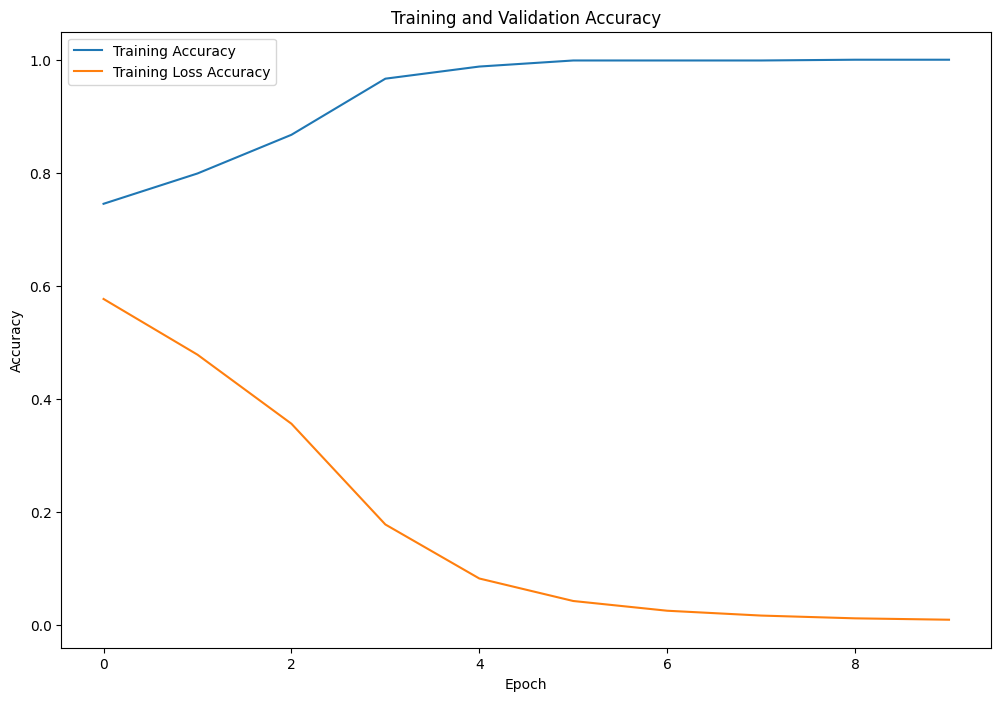

In [ ]:
plt.figure(figsize=(12, 8))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['loss'], label='Training Loss Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.7450 - loss: 0.5765 - val_accuracy: 0.7647 - val_loss: 0.5422
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7987 - loss: 0.4779 - val_accuracy: 0.7594 - val_loss: 0.5290
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8671 - loss: 0.3556 - val_accuracy: 0.7968 - val_loss: 0.4733
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9664 - loss: 0.1773 - val_accuracy: 0.7166 - val_loss: 0.5343
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9879 - loss: 0.0817 - val_accuracy: 0.7433 - val_loss: 0.5339
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9987 - loss: 0.0418 - val_accuracy: 0.7914 - val_loss: 0.5601
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9987 - loss: 0.0246 - val_accuracy: 0.7540 - val_loss: 0.6178
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9987 - loss: 0.0160 - val_accuracy: 0.7701 - v

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f'\nTest Accuracy: {accuracy:.2%}')

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7647 - loss: 0.7024 

Test Accuracy: 76.47%


In [ ]:
new_review = ["Amazing product, works perfectly and great build quality"]

# Tokenize and pad the new review
new_seq = tokenizer.texts_to_sequences(new_review)
new_padded = pad_sequences(new_seq, maxlen=MAX_LEN)

# Predict
prediction = model.predict(new_padded)
prob = prediction[0][0]

print(f'Prediction probability: {prob:.4f}')
if prob > 0.5:
    print('Sentiment: Positive 😊')
else:
    print('Sentiment: Negative ☹️')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
Prediction probability: 0.9785
Sentiment: Positive 😊
